### 군집화(clustering): 비지도학습의 일종으로, 비슷한 개체끼리 묶고 다른 개체는 다른 그룹으로 묶어 각 개체의 군집을 알아내는 것이 주요 목적

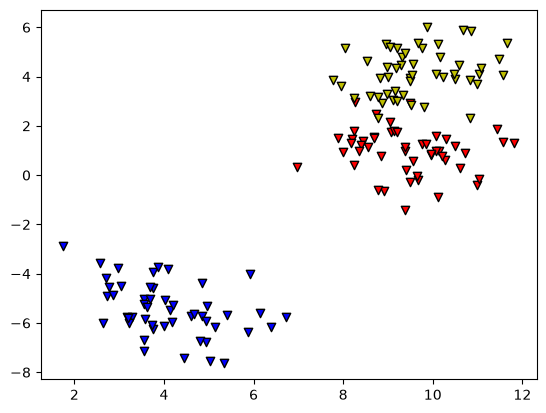

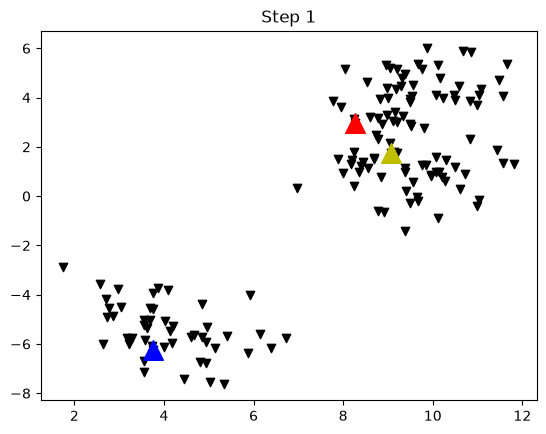

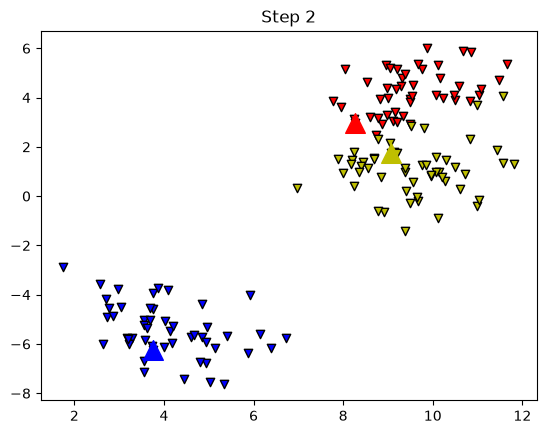

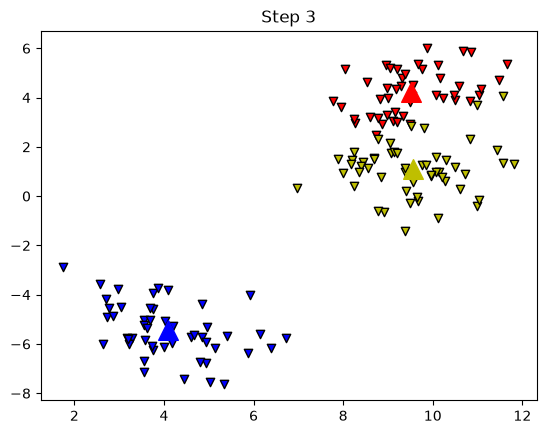

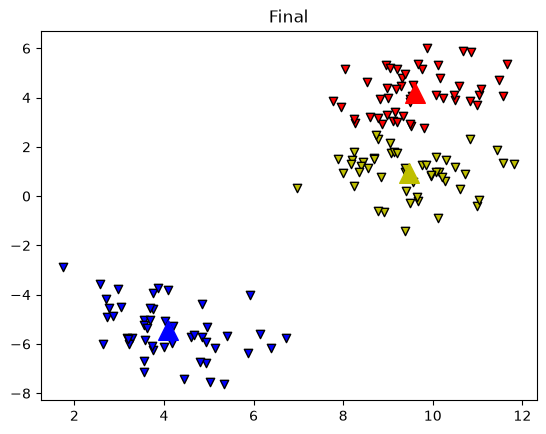

In [16]:
# k-평균 군집화: 전체 데이터 중 군집을 이루고 싶은 수만큼 점을 찍어 중심으로 삼은 후 
# 나머지 각 점들이 자신과 가장 가까운(유클리드 거리 기준) 중심점을 찾아 해당 그룹으로 소속된 후 
# 각 그룹의 평균 위치로 중심점을 새로 옮김 (중심이 안 바뀔 때까지 반복)
# → 이 과정을 반복할수록 각 점과 중심 사이 거리의 합(inertia, J)이 점점 작아짐

from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

def plot_KMeans_step(X, centroid = None, cluster = None, step = ''):
  c0, c1, c2 = centroid
  if (cluster is None):
    plt.scatter(X[:, 0], X[:, 1], marker='v', facecolor='k', edgecolors='k')

  elif (cluster is not None):
    label = list(cluster.values())
    plt.scatter(X[[l == 0 for l in label], 0], X[[l == 0 for l in label], 1], marker='v', facecolor='r', edgecolors='k')
    plt.scatter(X[[l == 1 for l in label], 0], X[[l == 1 for l in label], 1], marker='v', facecolor='y', edgecolors='k')
    plt.scatter(X[[l == 2 for l in label], 0], X[[l == 2 for l in label], 1], marker='v', facecolor='b', edgecolors='k')

  plt.scatter(c0[0], c0[1], marker='^', c='r', s=200)
  plt.scatter(c1[0], c1[1], marker='^', c='y', s=200)
  plt.scatter(c2[0], c2[1], marker='^', c='b', s=200)

  plt.title(step)
  plt.show()

X, y = make_blobs(n_samples=150, centers=3, random_state=4)

# 이미 정답을 알고 있는 시각화
plt.scatter(X[y == 0, 0], X[y == 0 , 1], marker='v', facecolor='r', edgecolors='k')
plt.scatter(X[y == 1, 0], X[y == 1 , 1], marker='v', facecolor='y', edgecolors='k')
plt.scatter(X[y == 2, 0], X[y == 2 , 1], marker='v', facecolor='b', edgecolors='k')
plt.show()
# 임의 중심점 잡기
def step_1(X, random_state=4):
  # ranodm 모듈 사용 시 고정값 배출을 위한 작업
  np.random.seed(random_state)
  i0, i1, i2 = np.random.randint(20, size=3)
  c0, c1, c2 = X[i0,:], X[i1, :], X[i2, :]
  return c0, c1, c2

c = step_1(X)

plot_KMeans_step(X, c, step='Step 1')

# 각 데이터 포인트에서 centroid에 가까운 군집으로 할당하는 함수
def step_2(X, centroid):
  
  # 두 벡터 x1, x2 사이의 유클리드 거리를 구하는 함수
  def dist(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))
  
  # cluster dictionary 에 샘플의 id를 key 로 하고, 각 샘플의 군집 id를 value로 저장합니다.
  cluster = {}
  # 각 샘플에 대해서 반복하여 수행합니다.
  for i in range(X.shape[0]):
    d = []
    # 각 군집에 대해서 각 샘플과의 거리를 측정하여 가장 가까운 군집으로 해당 샘플을 할당합니다.
    for c in centroid:
      d.append( dist(X[i,:], c))
    cluster[i] = d.index(min(d))
          
  return cluster

cluster = step_2(X, c)
plot_KMeans_step(X, c, cluster, step = 'Step 2')

def step_3(cluster, X):
  # 군집의 중심을 저장하는 list에 3개의 군집에 대해서 2차원의 중심 벡터를 저장합니다.
  new_centroid = [[], [], []]
  
  # 각 군집에 속한 샘플의 평균으로 군집의 중심을 업데이트하기 위해서 각 군집으로 할당된 샘플을 모읍니다.
  pool_0 = X[[x == 0 for x in cluster.values()], :]
  pool_1 = X[[x == 1 for x in cluster.values()], :]
  pool_2 = X[[x == 2 for x in cluster.values()], :]
  
  # 각 군집에 속한 샘플의 평균으로 군집의 중심을 업데이트 합니다.
  new_centroid[0] = np.mean(pool_0, 0)
  new_centroid[1] = np.mean(pool_1, 0)
  new_centroid[2] = np.mean(pool_2, 0)
  
  return new_centroid

centroid = step_3(cluster, X)
plot_KMeans_step(X, centroid, cluster, step = 'Step 3')

def step_4( centroid, cluster, X, max_iter = 100 ):
  # max_iter 의 값 만큼 iteration을 돌립니다.
  for _ in range(max_iter):
    # Step 2,3을 수행합니다.
    new_cluster = step_2(X, centroid)
    new_centroid = step_3(new_cluster, X)
    # centroid 변화가 없으면 중지, 그렇지 않은 경우, cluster와 centroid를 업데이트 합니다.
    if (np.concatenate(centroid) == np.concatenate(new_centroid)).all():
      break
    else:
      centroid = new_centroid
      cluster = new_cluster
  
  return centroid, cluster

centroid, cluster = step_4(centroid, cluster, X)
plot_KMeans_step(X, centroid, cluster, step = 'Final')

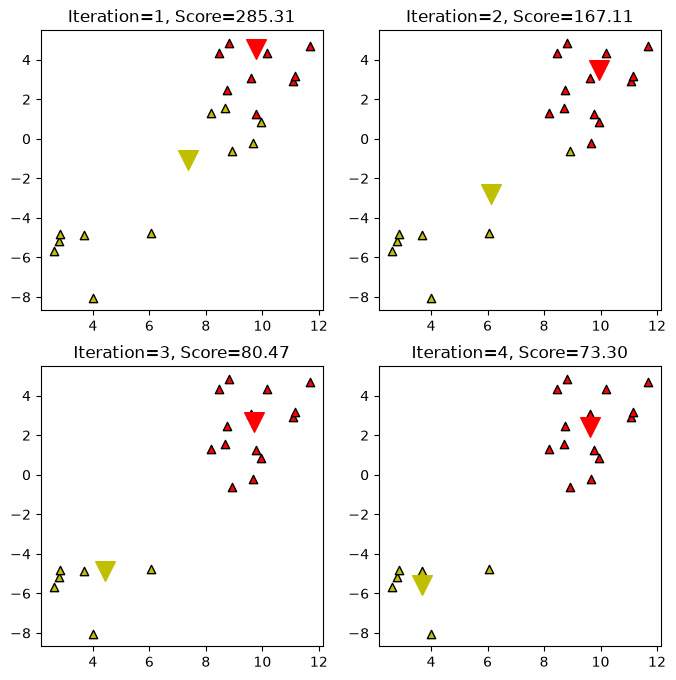

In [34]:
# k-mean 실무 코드
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=20, random_state=4)

def plot_KMeans(n):
  # n_clusters: 구별할 군집의 개수
  # init: 중심점 뽑는 방법(이 방법으로 n_init만큼 반복), 보통 기본값(k-means++ - 이미 뽑힌 점과 멀면 후보될 확률 높아짐) 씀
  # n_init: 중심점 시도 횟수(시도 횟수 중 가장 좋은 걸 택함)
  # max_iter: Step2(군집할당)-Step3(중심갱신) 반복을 최대 몇 번까지 허용할지

  # 흐름: init으로 중심점 뽑는 방법을 정한 뒤
  # n_init번 만큼 아래 과정을 각각 처음부터 끝까지 반복함:
  #   → 초기 중심 뽑기 → (군집 정하기 - 평균으로 이동하기)를 max_iter만큼 반복 → 수렴
  # 이렇게 나온 n_init개의 결과 중, 목적함수 J(inertia)가 가장 낮은 것을 최종 채택
  model = KMeans(n_clusters=2, init='random', n_init=1, max_iter=n, random_state=6).fit(X)

  # 군집화 결과, 군집 중심은 cluster_centers_
  # 할당된 군집은 labels_ 에 저장됨
  # 최종 목적 함수의 값은 score에 저장함
  c0, c1 = model.cluster_centers_

  plt.scatter(X[model.labels_ == 0, 0], X[model.labels_ == 0, 1], marker='^', facecolor='r', edgecolors='k')
  plt.scatter(X[model.labels_ == 1, 0], X[model.labels_ == 1, 1], marker='^', facecolor='y', edgecolors='k')
  plt.scatter(c0[0], c0[1], marker='v', c="r", s=200)
  plt.scatter(c1[0], c1[1], marker='v', c="y", s=200)

  # score 관례상 높을수록 좋으므로 점수가 -230보다 -70이 좋으나 inertia 기준으로 봐야 편하므로 -를 붙임
  plt.title(f"Iteration={n}, Score={-model.score(X):.2f}")
  return model.labels_

plt.figure(figsize=(8, 8))
plt.subplot(221)
cluster1 = plot_KMeans(1)
plt.subplot(222)
cluster2 = plot_KMeans(2)
plt.subplot(223)
cluster3 = plot_KMeans(3)
plt.subplot(224)
cluster4 = plot_KMeans(4)

In [40]:
# Silhouette index: 여러 K(군집 개수) 후보를 각각 시도해서 점수를 구하고,
# 그 점수가 1에 가장 가까운(=가장 높은) K를 최종 군집 개수로 채택함
from sklearn.metrics import silhouette_score
print(silhouette_score(X, cluster1))
print(silhouette_score(X, cluster2))
print(silhouette_score(X, cluster3))
print(silhouette_score(X, cluster4))

0.3739490988094139
0.6533298542098658
0.7409511696598068
0.7409511696598068


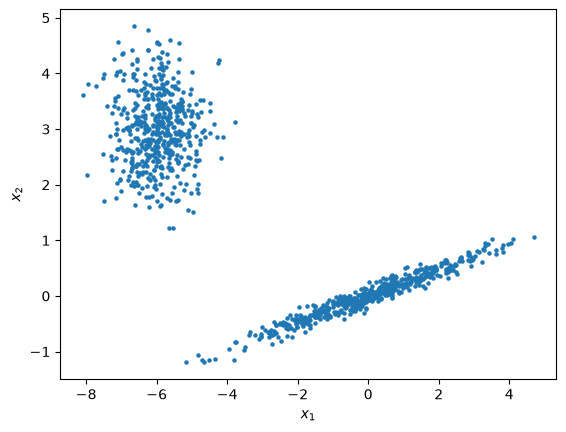

In [2]:
# GMM: 중심점과 퍼짐 정도를 가지고 각 점이 그룹에 속할 확률을 계산함
# 확률이 높은 점에 가중치를 더 부여하고 이를 기준으로 중심을 이동한 후 퍼짐을 갱신
# 중심점의 위치를 처음부터 잘 잡아야 하고(지역 최적해 문제), k-means처럼 K를 사용자가 정해야 하며 별도 평가로 K를 선정해야 한다.

import numpy as np
from numpy.random import randn
from matplotlib import pyplot as plt

n_samples = 500

pi1 = 1.0
pi2 = 0.7
mu1 = np.array([0, 0])
mu2 = np.array([-6, 3])
sigma1 = np.array([[0., -0.1], [1.7, .4]])
sigma2 = np.eye(2)

np.random.seed(0)
X = np.r_[pi1 * np.dot(randn(n_samples, 2), sigma1) + mu1,
          pi2 * np.dot(randn(n_samples, 2), sigma2) + mu2]
plt.scatter(X[:, 0], X[:, 1], s=5)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

c:\dev\workspace\next_ai\venv\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
c:\dev\workspace\next_ai\venv\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
c:\dev\workspace\next_ai\venv\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
c:\dev\workspace\next_ai\venv\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warning

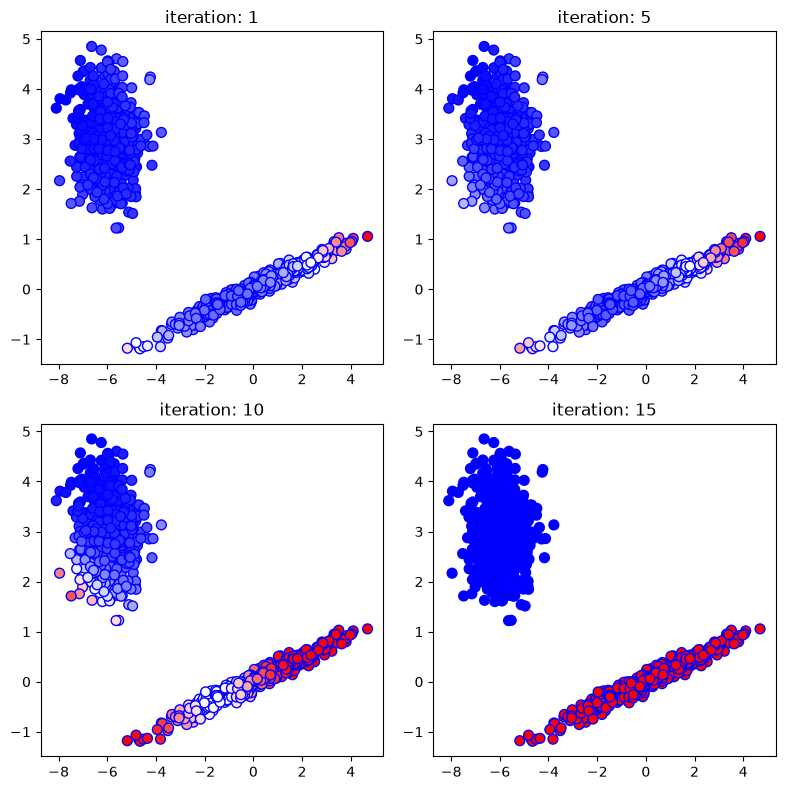

In [ ]:
from sklearn.mixture import GaussianMixture

def plot_gaussianmixture(n):
  # n_components: 군집의 수
  # guassian도 init_params는 kmeans가 default
  # tol: 수렴 판별값 (반복마다 우도(likelihood - 추측이 맞는 정도)가 얼마나 좋아지는지 확인해서, 그 개선폭이 이 값보다 작아지면 학습을 멈춤)
  model = GaussianMixture(n_components=2, init_params='random', random_state=0, tol=1e-9, max_iter=n)

  # 데이터를 학습합니다.
  model.fit(X)
  # 학습 결과 각 데이터에 대한 군집의 확률을 예측합니다.
  res = model.predict_proba(X)
  
  # 결과 출력 부분
  # 인수 c, color로 주어지는 값이 높고 낮음에 따라 cmap, colormap에서 값에 해당하는 색으로 출력
  plt.scatter(X[:, 0], X[:, 1], s=50, linewidth=1, edgecolors="b", cmap=plt.cm.bwr, c=res[:, 0])
  # 각 출력마다 몇 번의 iteration을 수행했는지를 출력
  plt.title("iteration: {}".format(n))

plt.figure(figsize=(8, 8))
plt.subplot(221)
plot_gaussianmixture(1)
plt.subplot(222)
plot_gaussianmixture(5)
plt.subplot(223)
plot_gaussianmixture(10)
plt.subplot(224)
plot_gaussianmixture(15)
plt.tight_layout()
plt.show()